# FNO Model 3 (Omega + 3 channels, 4 total) 16x16x16 train/val + 64x64x64 test (test data to be generated)
# FNO model of folder wise distribution for train-test-val. Poor val,test loss and good train loss - overfit
# Difficult to generalise to unseen data via this manner


In [1]:
# =========================
# Imports and experiment configuration (3D grid training)
# =========================
import glob
import random
import re
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from cycler import cycler
from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

# Central config: edit here only.
CFG = {
    # Random seed for reproducibility across numpy/torch/data split steps.
    'seed': 42,
    # Switch for quick preliminary runs before full-scale training.
    'fast_sanity_mode': False,

    # Optional dataset root used for relative paths.
    'data_root': '.',

    # Folder-holdout split: each split gets distinct folders.
    # This guarantees test files come from an unseen dataset folder.
    'split_mode': 'folder_holdout',
    'train_dirs': [
        'train/pair_1_fno_32/',
        'train/pair_4_fno_32/',
        'train/pair_5_fno_32/',
    ],
    'val_dirs': [
        'train/pair_3_fno_32/',
    ],
    'test_dirs': [
        'train/pair_2_fno_32/',
    ],
    # Keep SR disabled for now (can be enabled later).
    'test_sr_dirs': [],
    # Folders used only for visual candidate comparison.
    'candidate_preview_dirs': [
        'train/pair_1_fno_32/',
        'train/pair_2_fno_32/',
        'train/pair_3_fno_32/',
        'train/pair_4_fno_32/',
        'train/pair_5_fno_32/',
    ],

    # Use one folder per split for timeline plotting (same dataset across all 4 snapshots).
    'preferred_train_folder': 'pair_4_fno_32, pair_5_fno_32',
    'preferred_val_folder': 'pair_3_fno_32',
    'preferred_test_folder': 'pair_2_fno_32',

    # Timeline selection settings: 4 distant snapshots, not starting at frame 0.
    'timeline_n_cols': 4,
    'timeline_fractions': [0.18, 0.42, 0.70, 0.92],
    'timeline_start_frac': 0.10,

    # Skip initial frames to avoid startup transient.
    'min_frame_trainval': 10,
    'min_frame_test': 10,
    'min_frame_sr': 10,

    # 3D resolution checks.
    'train_expected_res': 32,
    'test_expected_res': 32,
    'test_sr_expected_res': 'auto',

    # Require a real test split by default.
    'allow_missing_test_dirs': False,

    # Optional file caps for quick sanity runs.
    'max_train_files': 256,
    'max_val_files': 96,
    'max_test_files': 96,
    'max_test_sr_files': None,

    # Spatial subsampling stride in dataset loader.
    'train_grid_stride': 1,
    'val_grid_stride': 1,
    'test_grid_stride': 1,

    # Feature scaling controls (computed from TRAIN split only).
    'normalize_inputs': True,
    'normalize_targets': True,
    'strict_normalization': True,
    'norm_eps': 1e-6,
    'norm_max_files': 192,

    # DataLoader tuning.
    'num_workers': 0,
    'pin_memory': True,
    'prefetch_factor': 2,

    # Training loop diagnostics/shortcuts.
    'log_every_batches': 10,
    'max_batches_per_epoch': None,  # set int for quick sanity runs

    # Optimization.
    'batch_size': 2,
    'epochs': 120,
    'lr': 1e-3,
    'weight_decay': 1e-4,

    # FNO architecture.
    'n_modes': (10, 10, 10),
    'hidden_channels': 64,
    'projection_channel_ratio': 2,

    # Evaluate every N epochs.
    'eval_every': 1,

    # Strict output checks for model inference.
    'strict_output_shape': True,

    # Use best validation checkpoint for all plots/diagnostics.
    'use_best_checkpoint_for_reports': True,

    # Optional diagnostics (disabled to keep workflow focused).
    'enable_optional_plots': False,

    # Plot styling.
    'plot_dpi': 300,
    'use_latex_font_style': True,
    'plot_field_cmap': 'viridis',
    'plot_error_cmap': 'magma',

    # Variant-specific fields.
    'input_channels': 4,
    'input_key': 'input_grid_omega4',
    'file_tag': 'fno_model3_3d',
}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG['seed'])
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NON_BLOCKING = DEVICE == 'cuda'

if CFG.get('use_latex_font_style', True):
    # Use LaTeX-like style without requiring a TeX install.
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'cm',
        'text.usetex': False,
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'axes.prop_cycle': cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']),
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'image.cmap': CFG.get('plot_field_cmap', 'viridis'),
    })

print('Python executable:', sys.executable)
print('Torch version:', torch.__version__)
print('Torch CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
if DEVICE == 'cuda':
    print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
else:
    print('Device:', DEVICE)
    print('[warn] CUDA is not available in this notebook kernel. If gpu_test.py succeeds in fno-env, switch Jupyter to that environment before training.')

print('Variant:', CFG['input_key'], 'channels=', CFG['input_channels'])
print('Split mode:', CFG['split_mode'])
print('Train dirs:', CFG['train_dirs'])
print('Val dirs:', CFG['val_dirs'])
print('Test dirs:', CFG['test_dirs'])
print('Timeline columns:', CFG['timeline_n_cols'], '| fractions:', CFG['timeline_fractions'])
print('Fast sanity mode:', CFG['fast_sanity_mode'])
print('Allow missing test dirs:', CFG['allow_missing_test_dirs'])
print('File caps train/val/test/test_sr:', CFG['max_train_files'], CFG['max_val_files'], CFG['max_test_files'], CFG['max_test_sr_files'])
print('Grid stride train/val/test:', CFG['train_grid_stride'], CFG['val_grid_stride'], CFG['test_grid_stride'])
print('Min frames train/val/test/sr:', CFG['min_frame_trainval'], CFG['min_frame_test'], CFG['min_frame_sr'])
print('Normalize inputs/targets:', CFG['normalize_inputs'], CFG['normalize_targets'])
print('Plot style:', {'field_cmap': CFG['plot_field_cmap'], 'error_cmap': CFG['plot_error_cmap'], 'dpi': CFG['plot_dpi']})

# Apply fast sanity settings (overrides) if enabled.
if CFG.get('fast_sanity_mode'):
    print('[info] FAST_SANITY mode enabled: applying lightweight settings')
    CFG['epochs'] = min(int(CFG.get('epochs', 1)), 5)
    CFG['eval_every'] = max(1, int(CFG.get('eval_every', 1)))
    CFG['max_train_files'] = min(int(CFG.get('max_train_files', 64) or 64), 64)
    CFG['max_val_files'] = min(int(CFG.get('max_val_files', 16) or 16), 16)
    CFG['max_test_files'] = min(int(CFG.get('max_test_files', 16) or 16), 16)
    CFG['max_test_sr_files'] = min(int(CFG.get('max_test_sr_files', 16) or 16), 16)
    CFG['max_batches_per_epoch'] = int(CFG.get('max_batches_per_epoch') or 5)
    CFG['log_every_batches'] = int(CFG.get('log_every_batches') or 5)
    CFG['test_sr_dirs'] = []
    CFG['epochs'] = max(1, CFG['epochs'])
    print('[info] FAST_SANITY settings applied:', {
        'epochs': CFG['epochs'],
        'eval_every': CFG['eval_every'],
        'max_train_files': CFG['max_train_files'],
        'max_val_files': CFG['max_val_files'],
        'max_test_files': CFG['max_test_files'],
        'max_test_sr_files': CFG['max_test_sr_files'],
        'max_batches_per_epoch': CFG['max_batches_per_epoch'],
        'log_every_batches': CFG['log_every_batches'],
        'test_sr_dirs': CFG['test_sr_dirs'],
    })


Python executable: c:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\fno-env\Scripts\python.exe
Torch version: 2.6.0+cu124
Torch CUDA build: 12.4
CUDA available: True
Device: cuda | GPU: NVIDIA RTX 4000 Ada Generation
Variant: input_grid_omega4 channels= 4
Split mode: folder_holdout
Train dirs: ['train/pair_1_fno_32/', 'train/pair_4_fno_32/', 'train/pair_5_fno_32/']
Val dirs: ['train/pair_3_fno_32/']
Test dirs: ['train/pair_2_fno_32/']
Timeline columns: 4 | fractions: [0.18, 0.42, 0.7, 0.92]
Fast sanity mode: False
Allow missing test dirs: False
File caps train/val/test/test_sr: 256 96 96 None
Grid stride train/val/test: 1 1 1
Min frames train/val/test/sr: 10 10 10
Normalize inputs/targets: True True
Plot style: {'field_cmap': 'viridis', 'error_cmap': 'magma', 'dpi': 300}


In [2]:
# =========================
# Data setup (3D train/val/test) + normalization
# =========================
cwd = Path.cwd().resolve()
if (cwd / '.git').exists():
    REPO_ROOT = cwd
elif (cwd.parent / '.git').exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd

data_root_cfg = CFG.get('data_root')
if data_root_cfg in (None, '', '.'):
    DATA_ROOT = REPO_ROOT
else:
    data_root_path = Path(data_root_cfg).expanduser()
    if data_root_path.is_absolute():
        DATA_ROOT = data_root_path.resolve()
    else:
        # Resolve relative data_root from repo root, not notebook cwd.
        DATA_ROOT = (REPO_ROOT / data_root_path).resolve()

print('Detected REPO_ROOT:', REPO_ROOT)
print('DATA_ROOT:', DATA_ROOT)

RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Results directory:', RESULTS_DIR)

ALLOW_MISSING_TEST = bool(CFG.get('allow_missing_test_dirs')) or bool(CFG.get('fast_sanity_mode'))


def save_fig(fig, filename, dpi=None):
    dpi_use = int(dpi or CFG.get('plot_dpi', 300))
    out = RESULTS_DIR / f"{CFG['file_tag']}_{filename}"
    fig.savefig(out, dpi=dpi_use, bbox_inches='tight')
    print(f'[saved] {out}')


def resolve_dirs(path_list, must_exist=True, base_root=DATA_ROOT):
    dirs = []
    for d in path_list:
        p = Path(d).expanduser()
        if p.is_absolute():
            candidates = [p.resolve()]
        else:
            candidates = [(base_root / p).resolve()]
            # Fallback to repo-root relative path to avoid cwd-dependent failures.
            repo_candidate = (REPO_ROOT / p).resolve()
            if repo_candidate not in candidates:
                candidates.append(repo_candidate)

        found = next((c for c in candidates if c.is_dir()), None)
        if found is not None:
            dirs.append(found)
            continue

        if must_exist:
            tried = ' | '.join(str(c) for c in candidates)
            raise FileNotFoundError(f'Missing directory: {p}. Tried: {tried}')
        else:
            print(f'[warn] directory missing, skipping: {candidates[0]}')
    return dirs


TRAIN_DIRS = resolve_dirs(CFG.get('train_dirs', []), must_exist=True)
VAL_DIRS = resolve_dirs(CFG.get('val_dirs', []), must_exist=True)
TEST_DIRS = resolve_dirs(CFG.get('test_dirs', []), must_exist=not ALLOW_MISSING_TEST)
TEST_SR_DIRS = resolve_dirs(CFG.get('test_sr_dirs', []), must_exist=False)
PREVIEW_DIRS = resolve_dirs(CFG.get('candidate_preview_dirs', []), must_exist=False)

if len(TRAIN_DIRS) == 0:
    raise RuntimeError('No train directories configured. Fill CFG["train_dirs"].')
if len(VAL_DIRS) == 0:
    raise RuntimeError('No validation directories configured. Fill CFG["val_dirs"].')
if not ALLOW_MISSING_TEST and len(TEST_DIRS) == 0 and len(TEST_SR_DIRS) == 0:
    raise RuntimeError('No test/test_sr dirs provided and allow_missing_test_dirs=False')


FRAME_RE = re.compile(r'frame_(\d+)', re.IGNORECASE)


def parse_frame_id(path_like):
    name = Path(path_like).name
    m = FRAME_RE.search(name)
    if not m:
        raise ValueError(f'Cannot parse frame id from filename: {name}')
    return int(m.group(1))


def list_frame_files(sim_dir, expect_gridded=True):
    grid_files = sorted(
        glob.glob(str(sim_dir / 'frame_*_grid.npz')),
        key=parse_frame_id,
    )
    if grid_files:
        return grid_files

    raw_files = sorted(
        glob.glob(str(sim_dir / 'frame_*.npz')),
        key=parse_frame_id,
    )

    if raw_files and expect_gridded:
        sample = np.load(raw_files[0])
        raise RuntimeError(
            f"Directory {sim_dir} has raw frame_*.npz ({len(raw_files)} files) but no frame_*_grid.npz. "
            f"Sample keys: {list(sample.files)}. "
            "This notebook expects gridded data with U_grid/input_grid_* keys. "
            "Run dataset_gen/autodomain_particle_grid.py and point CFG train/test dirs to pair_*_fno* folders."
        )

    return raw_files


def gridded_file_is_valid(file_path, input_key, expected_channels):
    if Path(file_path).stat().st_size == 0:
        return False, 'empty_file'

    try:
        d = np.load(file_path)
    except Exception as exc:
        return False, f'load_error: {exc}'

    if input_key not in d:
        return False, f"missing_input_key:{input_key}"
    if 'U_grid' not in d:
        return False, 'missing_output_key:U_grid'

    x = np.asarray(d[input_key], dtype=np.float32)
    y = np.asarray(d['U_grid'], dtype=np.float32)

    if x.ndim != 4 or y.ndim != 4:
        return False, f'bad_rank:x{tuple(x.shape)}_y{tuple(y.shape)}'
    if x.shape[0] != expected_channels:
        return False, f'bad_input_channels:{x.shape[0]}!=exp{expected_channels}'
    if y.shape[0] != 3:
        return False, f'bad_output_channels:{y.shape[0]}'
    if x.shape[-3:] != y.shape[-3:]:
        return False, f'res_mismatch:x{tuple(x.shape[-3:])}_y{tuple(y.shape[-3:])}'

    if not np.isfinite(x).all():
        return False, 'non_finite_input'
    if not np.isfinite(y).all():
        return False, 'non_finite_output'

    return True, 'ok'


def filter_valid_gridded_files(files, input_key, expected_channels, label, max_report=5):
    valid = []
    dropped = []
    for fp in files:
        ok, reason = gridded_file_is_valid(fp, input_key=input_key, expected_channels=expected_channels)
        if ok:
            valid.append(fp)
        else:
            dropped.append((fp, reason))

    if dropped:
        print(f"[warn] {label}: dropped {len(dropped)} invalid files")
        for fp, reason in dropped[:max_report]:
            print(f"    - {Path(fp).name}: {reason}")
        if len(dropped) > max_report:
            print(f"    ... and {len(dropped) - max_report} more")

    return valid


def filter_by_min_frame(files, min_frame, label):
    if min_frame in (None, 0):
        return files
    kept = [f for f in files if parse_frame_id(f) >= min_frame]
    if len(kept) != len(files):
        print(f"[info] {label} frame filter: kept {len(kept)}/{len(files)} with frame >= {min_frame}")
    return kept


def collect_files_from_dirs(dirs, split_label, min_frame):
    all_files = []
    per_dir_counts = {}
    for d in dirs:
        files = list_frame_files(d, expect_gridded=True)
        if len(files) == 0:
            print(f"[warn] no frame files found in {split_label} dir: {d}")
            continue

        files = filter_valid_gridded_files(
            files,
            input_key=CFG['input_key'],
            expected_channels=CFG['input_channels'],
            label=f"{d.name} ({split_label})",
        )
        files = filter_by_min_frame(files, min_frame, f"{d.name} ({split_label})")
        all_files.extend(files)
        per_dir_counts[d.name] = len(files)
        print(f"[info] {split_label} {d.name}: valid_total={len(files)}")
    return all_files, per_dir_counts


TRAIN_FILES, TRAIN_COUNTS = collect_files_from_dirs(TRAIN_DIRS, 'train', CFG['min_frame_trainval'])
VAL_FILES, VAL_COUNTS = collect_files_from_dirs(VAL_DIRS, 'val', CFG['min_frame_trainval'])
TEST_FILES, TEST_COUNTS = collect_files_from_dirs(TEST_DIRS, 'test', CFG['min_frame_test'])
TEST_SR_FILES, TEST_SR_COUNTS = collect_files_from_dirs(TEST_SR_DIRS, 'test_sr', CFG['min_frame_sr'])

HAS_TEST = len(TEST_FILES) > 0
HAS_TEST_SR = len(TEST_SR_FILES) > 0

if len(TRAIN_FILES) == 0:
    raise RuntimeError("No training files found after directory scan/filtering. Check CFG['train_dirs'].")
if len(VAL_FILES) == 0:
    raise RuntimeError("Validation set is empty after filtering. Check CFG['val_dirs'].")
if not ALLOW_MISSING_TEST and not HAS_TEST and not HAS_TEST_SR:
    raise RuntimeError("Test split is empty but allow_missing_test_dirs=False.")


def folder_names(files):
    return {Path(f).parent.name for f in files}


train_folders = folder_names(TRAIN_FILES)
val_folders = folder_names(VAL_FILES)
test_folders = folder_names(TEST_FILES)

if len(train_folders.intersection(val_folders)) > 0:
    raise RuntimeError(f'Train/val folder overlap detected: {sorted(train_folders.intersection(val_folders))}')
if len(train_folders.intersection(test_folders)) > 0:
    raise RuntimeError(f'Train/test folder overlap detected: {sorted(train_folders.intersection(test_folders))}')
if len(val_folders.intersection(test_folders)) > 0:
    raise RuntimeError(f'Val/test folder overlap detected: {sorted(val_folders.intersection(test_folders))}')

print('[info] split folders -> train:', sorted(train_folders), '| val:', sorted(val_folders), '| test:', sorted(test_folders))


def cap_files(files, cap, seed_shift, label):
    if not cap or len(files) <= cap:
        return files
    rng = np.random.default_rng(CFG['seed'] + seed_shift)
    idx = rng.choice(len(files), size=cap, replace=False)
    capped = [files[i] for i in sorted(idx.tolist())]
    print(f"[info] {label} file cap active: using {len(capped)} files")
    return capped


TRAIN_FILES = cap_files(TRAIN_FILES, CFG.get('max_train_files'), 1101, 'train')
VAL_FILES = cap_files(VAL_FILES, CFG.get('max_val_files'), 1201, 'val')
TEST_FILES = cap_files(TEST_FILES, CFG.get('max_test_files'), 1301, 'test')
TEST_SR_FILES = cap_files(TEST_SR_FILES, CFG.get('max_test_sr_files'), 1401, 'test_sr')

TRAIN_FILES = filter_by_min_frame(TRAIN_FILES, CFG['min_frame_trainval'], 'TRAIN_FILES (post)')
VAL_FILES = filter_by_min_frame(VAL_FILES, CFG['min_frame_trainval'], 'VAL_FILES (post)')
TEST_FILES = filter_by_min_frame(TEST_FILES, CFG['min_frame_test'], 'TEST_FILES (post)')
TEST_SR_FILES = filter_by_min_frame(TEST_SR_FILES, CFG['min_frame_sr'], 'TEST_SR_FILES (post)')

HAS_TEST = len(TEST_FILES) > 0
HAS_TEST_SR = len(TEST_SR_FILES) > 0


def summarize_frame_range(files, label):
    if len(files) == 0:
        print(f'[{label}] no files')
        return
    frames = [parse_frame_id(f) for f in files]
    print(f'[{label}] frame range: {min(frames)}..{max(frames)} (n={len(frames)})')


def summarize_per_folder(files, label):
    c = defaultdict(int)
    for f in files:
        c[Path(f).parent.name] += 1
    print(f'[{label}] folder counts:', dict(sorted(c.items())))


print(f"Train files: {len(TRAIN_FILES)} | Val files: {len(VAL_FILES)} | Test files: {len(TEST_FILES)}")
print(f"Test SR files: {len(TEST_SR_FILES)}")
summarize_frame_range(TRAIN_FILES, 'TRAIN')
summarize_frame_range(VAL_FILES, 'VAL')
if HAS_TEST:
    summarize_frame_range(TEST_FILES, 'TEST')
if HAS_TEST_SR:
    summarize_frame_range(TEST_SR_FILES, 'TEST_SR')
summarize_per_folder(TRAIN_FILES, 'TRAIN')
summarize_per_folder(VAL_FILES, 'VAL')
if HAS_TEST:
    summarize_per_folder(TEST_FILES, 'TEST')


def preview_index_map(files, label, max_items=8):
    print(f"[{label}] index preview (first {min(len(files), max_items)} entries)")
    for i, fp in enumerate(files[:max_items]):
        pp = Path(fp)
        print(f"  idx={i:03d} folder={pp.parent.name} frame={parse_frame_id(fp)} file={pp.name}")


preview_index_map(TRAIN_FILES, 'TRAIN')
preview_index_map(VAL_FILES, 'VAL')
if HAS_TEST:
    preview_index_map(TEST_FILES, 'TEST')
if HAS_TEST_SR:
    preview_index_map(TEST_SR_FILES, 'TEST_SR')


def load_x(data):
    key = CFG['input_key']
    if key not in data:
        raise KeyError(f"Missing key '{key}'. Available: {data.files}")
    x = np.asarray(data[key], dtype=np.float32)
    return x


def infer_expected_res(file_path):
    d = np.load(file_path)
    x = load_x(d)
    if x.ndim >= 4:
        return int(x.shape[-1])
    return None


def resolve_expected_res(files, expected_res, label):
    if len(files) == 0:
        return expected_res
    actual = infer_expected_res(files[0])
    if expected_res in (None, 'auto'):
        print(f"[info] {label} expected_res auto-set to {actual}")
        return actual
    if actual is not None and actual != expected_res:
        print(f"[warn] {label} expected_res={expected_res} but data shows {actual}; using data value")
        return actual
    return expected_res


def assert_shapes(files, expected_channels, expected_res=None, label='set'):
    if len(files) == 0:
        return

    bad = []
    for f in files:
        d = np.load(f)
        x = load_x(d)
        y = np.asarray(d['U_grid'], dtype=np.float32)

        ok_channels = (x.shape[0] == expected_channels and y.shape[0] == 3)
        ok_rank = (x.ndim == 4 and y.ndim == 4)

        ok_res = True
        if expected_res is not None:
            ok_res = (
                x.shape[-3:] == (expected_res, expected_res, expected_res)
                and y.shape[-3:] == (expected_res, expected_res, expected_res)
            )

        if not (ok_channels and ok_rank and ok_res):
            bad.append((f, tuple(x.shape), tuple(y.shape)))
            if len(bad) >= 5:
                break

    if bad:
        msg = '\n'.join([f"{fp} -> x:{xs}, y:{ys}" for fp, xs, ys in bad])
        raise RuntimeError(f"{label} shape check failed. Examples:\n{msg}")


def assert_no_overlap(a, b, label_a='A', label_b='B'):
    inter = set(a).intersection(set(b))
    if inter:
        raise RuntimeError(f'{label_a}/{label_b} leakage detected with {len(inter)} overlapping files')


assert_no_overlap(TRAIN_FILES, VAL_FILES, 'train', 'val')
assert_no_overlap(TRAIN_FILES, TEST_FILES, 'train', 'test')
assert_no_overlap(VAL_FILES, TEST_FILES, 'val', 'test')

train_res = resolve_expected_res(TRAIN_FILES, CFG['train_expected_res'], 'train')
val_res = resolve_expected_res(VAL_FILES, CFG['train_expected_res'], 'val')
if HAS_TEST:
    test_res = resolve_expected_res(TEST_FILES, CFG['test_expected_res'], 'test')
else:
    test_res = CFG['test_expected_res']

CFG['train_expected_res'] = train_res
CFG['test_expected_res'] = test_res
if HAS_TEST_SR:
    test_sr_res = resolve_expected_res(TEST_SR_FILES, CFG.get('test_sr_expected_res', 'auto'), 'test_sr')
    CFG['test_sr_expected_res'] = test_sr_res
else:
    test_sr_res = CFG.get('test_sr_expected_res', None)

assert_shapes(TRAIN_FILES, expected_channels=CFG['input_channels'], expected_res=train_res, label='train')
assert_shapes(VAL_FILES, expected_channels=CFG['input_channels'], expected_res=val_res, label='val')
if HAS_TEST:
    assert_shapes(TEST_FILES, expected_channels=CFG['input_channels'], expected_res=test_res, label='test')
if HAS_TEST_SR:
    assert_shapes(TEST_SR_FILES, expected_channels=CFG['input_channels'], expected_res=test_sr_res, label='test_sr')


class Standardizer:
    def __init__(self, mean_x, std_x, mean_y, std_y, eps=1e-6):
        self.mean_x = mean_x
        self.std_x = std_x
        self.mean_y = mean_y
        self.std_y = std_y
        self.eps = eps

    def _reshape_like(self, stats, x):
        # Broadcast channel stats across spatial dims of x and keep them on
        # the same device/dtype as the working tensor.
        stats_t = torch.as_tensor(stats, dtype=x.dtype, device=x.device)
        if x.ndim == 4:
            # x: (C, Nx, Ny, Nz)
            return stats_t[:, None, None, None]
        if x.ndim == 5:
            # x: (B, C, Nx, Ny, Nz)
            return stats_t[None, :, None, None, None]
        raise RuntimeError(f'Unsupported tensor rank for normalization: {x.ndim}')

    def normalize_x(self, x):
        mean = self._reshape_like(self.mean_x, x)
        std = self._reshape_like(self.std_x, x)
        return (x - mean) / std

    def normalize_y(self, y):
        mean = self._reshape_like(self.mean_y, y)
        std = self._reshape_like(self.std_y, y)
        return (y - mean) / std

    def denormalize_y(self, y):
        mean = self._reshape_like(self.mean_y, y)
        std = self._reshape_like(self.std_y, y)
        return y * std + mean


def compute_channel_stats(files, key, nmax, stride, expected_channels, eps):
    files = list(files)
    if len(files) == 0:
        raise RuntimeError('No files provided for normalization stats')

    rng = np.random.default_rng(CFG['seed'])
    if nmax is not None and len(files) > nmax:
        idx = rng.choice(len(files), size=nmax, replace=False)
        files = [files[i] for i in idx]

    sum_c = np.zeros(expected_channels, dtype=np.float64)
    sumsq_c = np.zeros(expected_channels, dtype=np.float64)
    count = 0

    for fp in files:
        d = np.load(fp)
        arr = np.asarray(d[key], dtype=np.float32)
        if stride and stride > 1:
            arr = arr[:, ::stride, ::stride, ::stride]
        if arr.shape[0] != expected_channels:
            raise RuntimeError(f'Channel mismatch in {fp}: got {arr.shape[0]}, expected {expected_channels}')
        arr = arr.reshape(expected_channels, -1)
        sum_c += arr.sum(axis=1)
        sumsq_c += (arr ** 2).sum(axis=1)
        count += arr.shape[1]

    mean = sum_c / max(count, 1)
    var = sumsq_c / max(count, 1) - mean ** 2
    std = np.sqrt(np.maximum(var, eps ** 2))
    return mean.astype(np.float32), std.astype(np.float32)


if CFG['normalize_inputs'] or CFG['normalize_targets']:
    mean_x, std_x = compute_channel_stats(
        TRAIN_FILES,
        key=CFG['input_key'],
        nmax=CFG['norm_max_files'],
        stride=CFG['train_grid_stride'],
        expected_channels=CFG['input_channels'],
        eps=CFG['norm_eps'],
    )
    mean_y, std_y = compute_channel_stats(
        TRAIN_FILES,
        key='U_grid',
        nmax=CFG['norm_max_files'],
        stride=CFG['train_grid_stride'],
        expected_channels=3,
        eps=CFG['norm_eps'],
    )
    NORMALIZER = Standardizer(mean_x, std_x, mean_y, std_y, eps=CFG['norm_eps'])
else:
    NORMALIZER = None

if CFG['strict_normalization'] and (CFG['normalize_inputs'] or CFG['normalize_targets']) and NORMALIZER is None:
    raise RuntimeError('Normalization requested but NORMALIZER is None')


def normalize_input_tensor(x):
    if not CFG['normalize_inputs']:
        return x
    if NORMALIZER is None:
        raise RuntimeError('normalize_inputs=True but NORMALIZER is None')
    return NORMALIZER.normalize_x(x)


def normalize_target_tensor(y):
    if not CFG['normalize_targets']:
        return y
    if NORMALIZER is None:
        raise RuntimeError('normalize_targets=True but NORMALIZER is None')
    return NORMALIZER.normalize_y(y)


def denormalize_target_tensor(y):
    if not CFG['normalize_targets']:
        return y
    if NORMALIZER is None:
        raise RuntimeError('normalize_targets=True but NORMALIZER is None')
    return NORMALIZER.denormalize_y(y)


class GridDataset(Dataset):
    def __init__(self, files, grid_stride=1):
        self.files = list(files)
        self.grid_stride = 1 if grid_stride is None else int(grid_stride)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        x = torch.tensor(load_x(d), dtype=torch.float32)
        y = torch.tensor(np.asarray(d['U_grid'], dtype=np.float32), dtype=torch.float32)

        s = self.grid_stride
        if s > 1:
            x = x[:, ::s, ::s, ::s]
            y = y[:, ::s, ::s, ::s]

        x = normalize_input_tensor(x)
        y = normalize_target_tensor(y)
        return x, y


TRAIN_DS = GridDataset(TRAIN_FILES, grid_stride=CFG['train_grid_stride'])
VAL_DS = GridDataset(VAL_FILES, grid_stride=CFG['val_grid_stride'])
TEST_DS = GridDataset(TEST_FILES, grid_stride=CFG['test_grid_stride']) if HAS_TEST else None
TEST_SR_DS = GridDataset(TEST_SR_FILES, grid_stride=CFG['test_grid_stride']) if HAS_TEST_SR else None

if HAS_TEST_SR and CFG['test_grid_stride'] not in (None, 1):
    print('[warn] test_grid_stride is set; SR evaluation will be downsampled')

drop_last = len(TRAIN_DS) >= CFG['batch_size']
DL_KW = {
    'num_workers': int(CFG.get('num_workers', 0)),
    'pin_memory': bool(CFG.get('pin_memory', False)) and DEVICE == 'cuda',
    'persistent_workers': int(CFG.get('num_workers', 0)) > 0,
}
if DL_KW['num_workers'] > 0:
    DL_KW['prefetch_factor'] = int(CFG.get('prefetch_factor', 2))

TRAIN_LOADER = DataLoader(TRAIN_DS, batch_size=CFG['batch_size'], shuffle=True, drop_last=drop_last, **DL_KW)
VAL_LOADER = DataLoader(VAL_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW)
TEST_LOADER = DataLoader(TEST_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW) if HAS_TEST else None
TEST_SR_LOADER = DataLoader(TEST_SR_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW) if HAS_TEST_SR else None
print('DataLoader kwargs:', DL_KW)

xtr, ytr = TRAIN_DS[0]
xva, yva = VAL_DS[0]
print('Train sample shape:', tuple(xtr.shape), tuple(ytr.shape))
print('Val sample shape  :', tuple(xva.shape), tuple(yva.shape))
if HAS_TEST:
    xte, yte = TEST_DS[0]
    print('Test sample shape :', tuple(xte.shape), tuple(yte.shape))
    print('First TEST file   :', Path(TEST_FILES[0]).name)
elif len(CFG.get('test_dirs', [])) > 0:
    print('Test sample shape : [unavailable] no valid files loaded from test_dirs')
if HAS_TEST_SR:
    xsr, ysr = TEST_SR_DS[0]
    print('Test SR sample shape:', tuple(xsr.shape), tuple(ysr.shape))


Detected REPO_ROOT: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main
DATA_ROOT: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main
Results directory: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results
[warn] pair_1_fno_32 (train): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_1_fno_32 (train) frame filter: kept 190/199 with frame >= 10
[info] train pair_1_fno_32: valid_total=190
[warn] pair_4_fno_32 (train): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_4_fno_32 (train) frame filter: kept 198/199 with frame >= 10
[info] train pair_4_fno_32: valid_total=198
[warn] pair_5_fno_32 (train): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_5_fno_32 (train) frame filter: kept 175/179 with frame >= 10
[info] train pair_5_fno_32: valid_total=175
[warn] pair_3_fno_32 (val): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output

In [3]:
# =========================
# 3D FNO model + optimizer + metrics
# =========================
def build_model(cfg):
    return FNO(
        n_modes=cfg['n_modes'],
        in_channels=cfg['input_channels'],
        out_channels=3,
        hidden_channels=cfg['hidden_channels'],
        projection_channel_ratio=cfg['projection_channel_ratio'],
    ).to(DEVICE)


MODEL = build_model(CFG)

total_params = count_model_params(MODEL)
trainable_params = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print('Total params:', total_params)
print('Trainable params:', trainable_params)

OPT = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
SCH = torch.optim.lr_scheduler.CosineAnnealingLR(OPT, T_max=CFG['epochs'])
LOSS_FN = LpLoss(d=3, p=2)


def predict(model, x, expected_shape=None):
    y = model(x)
    if expected_shape is not None and y.shape != expected_shape:
        raise RuntimeError(f'Prediction shape {tuple(y.shape)} != expected {tuple(expected_shape)}')
    return y


def to_physical_y(t):
    # Convert model-space target/prediction tensors back to physical units for metrics/plots.
    return denormalize_target_tensor(t)


def batch_metrics(pred, target):
    if CFG['strict_output_shape'] and pred.shape != target.shape:
        raise RuntimeError(f'Output shape {tuple(pred.shape)} does not match target {tuple(target.shape)}')

    pred_phys = to_physical_y(pred)
    target_phys = to_physical_y(target)

    diff = pred_phys - target_phys
    mse = torch.mean(diff ** 2, dim=(1, 2, 3, 4))
    mae = torch.mean(torch.abs(diff), dim=(1, 2, 3, 4))
    rmse = torch.sqrt(mse)

    diff_flat = diff.reshape(diff.shape[0], -1)
    tgt_flat = target_phys.reshape(target_phys.shape[0], -1)
    rel_l2 = torch.linalg.norm(diff_flat, dim=1) / torch.linalg.norm(tgt_flat, dim=1).clamp_min(1e-12)

    return {
        'mse': mse.mean().item(),
        'mae': mae.mean().item(),
        'rmse': rmse.mean().item(),
        'rel_l2': rel_l2.mean().item(),
        'mse_sum': mse.sum().item(),
        'mae_sum': mae.sum().item(),
        'rmse_sum': rmse.sum().item(),
        'rel_l2_sum': rel_l2.sum().item(),
        'n': mse.shape[0],
        'rel_vec': rel_l2.detach().cpu().numpy(),
    }


@torch.no_grad()
def evaluate(model, loader, collect=False):
    if loader is None:
        return None

    model.eval()
    acc_sum = {'mse': 0.0, 'mae': 0.0, 'rmse': 0.0, 'rel_l2': 0.0}
    rels = []
    total_n = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=NON_BLOCKING)
        y = y.to(DEVICE, non_blocking=NON_BLOCKING)
        pred = predict(model, x, expected_shape=y.shape)
        m = batch_metrics(pred, y)
        for k in acc_sum:
            acc_sum[k] += m[f'{k}_sum']
        if collect:
            rels.extend(m['rel_vec'].tolist())
        total_n += m['n']

    if total_n == 0:
        return None

    acc = {k: acc_sum[k] / max(total_n, 1) for k in acc_sum}
    if collect:
        acc['rel_per_sample'] = np.asarray(rels, dtype=np.float32)
    return acc


def verify_sr_sample():
    if not HAS_TEST_SR:
        return
    xsr, ysr = TEST_SR_DS[0]
    with torch.no_grad():
        pred = predict(MODEL, xsr.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING), expected_shape=ysr.unsqueeze(0).shape)
    print('[verify_sr] input shape:', tuple(xsr.shape), 'target shape:', tuple(ysr.shape), 'pred shape:', tuple(pred.shape))


verify_sr_sample()


Total params: 19712451
Trainable params: 9882051


In [4]:
# =========================
import time
# Training loop (3D low-res train/val + optional test/test_sr)
# =========================
HIST = {
    'epoch': [],
    # LpLoss value in normalized target space (optimization objective).
    'train_lp': [],
    # Relative L2 in physical units for easier interpretation.
    'train_rel_l2': [],
    'val_rel_l2': [],
    'val_rmse': [],
    'test_rel_l2': [],
    'test_rmse': [],
    'test_sr_rel_l2': [],
    'test_sr_rmse': [],
    'lr': [],
}

best_val = float('inf')
CKPT_PATH = RESULTS_DIR / f"{CFG['file_tag']}_best_model.pt"

for epoch in range(1, CFG['epochs'] + 1):
    MODEL.train()
    run_loss = 0.0
    run_rel = 0.0
    nb = 0
    t_epoch = time.time()

    for b_idx, (x, y) in enumerate(TRAIN_LOADER, start=1):
        x = x.to(DEVICE, non_blocking=NON_BLOCKING)
        y = y.to(DEVICE, non_blocking=NON_BLOCKING)
        OPT.zero_grad(set_to_none=True)
        pred = predict(MODEL, x, expected_shape=y.shape)

        # Optimization loss in normalized space.
        loss = LOSS_FN(pred, y)
        loss.backward()
        OPT.step()

        run_loss += loss.item()
        run_rel += batch_metrics(pred.detach(), y)['rel_l2']
        nb += 1

        if CFG.get('log_every_batches') and b_idx % int(CFG['log_every_batches']) == 0:
            elapsed = time.time() - t_epoch
            print(f'  [epoch {epoch:03d}] batch {b_idx}/{len(TRAIN_LOADER)} loss={loss.item():.4e} elapsed={elapsed:.1f}s')

        if CFG.get('max_batches_per_epoch') is not None and b_idx >= int(CFG['max_batches_per_epoch']):
            print(f'  [epoch {epoch:03d}] early stop after {b_idx} batches (max_batches_per_epoch)')
            break

    SCH.step()
    train_lp = run_loss / max(nb, 1)
    train_rel = run_rel / max(nb, 1)

    if epoch % CFG['eval_every'] == 0:
        val_m = evaluate(MODEL, VAL_LOADER)
        test_m = evaluate(MODEL, TEST_LOADER) if HAS_TEST else None
        test_sr_m = evaluate(MODEL, TEST_SR_LOADER) if HAS_TEST_SR else None

        HIST['epoch'].append(epoch)
        HIST['train_lp'].append(train_lp)
        HIST['train_rel_l2'].append(train_rel)
        HIST['val_rel_l2'].append(val_m['rel_l2'])
        HIST['val_rmse'].append(val_m['rmse'])
        HIST['test_rel_l2'].append(test_m['rel_l2'] if test_m is not None else np.nan)
        HIST['test_rmse'].append(test_m['rmse'] if test_m is not None else np.nan)
        HIST['test_sr_rel_l2'].append(test_sr_m['rel_l2'] if test_sr_m is not None else np.nan)
        HIST['test_sr_rmse'].append(test_sr_m['rmse'] if test_sr_m is not None else np.nan)
        HIST['lr'].append(OPT.param_groups[0]['lr'])

        if val_m['rel_l2'] < best_val:
            best_val = val_m['rel_l2']
            torch.save(
                {
                    'model_state_dict': MODEL.state_dict(),
                    'config': dict(CFG),
                    'best_val_rel_l2': best_val,
                },
                CKPT_PATH,
            )

        epoch_time = time.time() - t_epoch
        msg = (
            f"[{epoch:03d}] train_lp(norm)={train_lp:.4e} "
            f"train_rel_l2(phys)={train_rel:.4e} "
            f"val_rel_l2(phys)={val_m['rel_l2']:.4e} val_rmse(phys)={val_m['rmse']:.4e} "
            f"lr={HIST['lr'][-1]:.2e} time={epoch_time:.1f}s"
        )
        if test_m is not None:
            msg += f" test_rel_l2(phys)={test_m['rel_l2']:.4e} test_rmse(phys)={test_m['rmse']:.4e}"
        if test_sr_m is not None:
            msg += f" test_sr_rel_l2(phys)={test_sr_m['rel_l2']:.4e} test_sr_rmse(phys)={test_sr_m['rmse']:.4e}"
        print(msg)

print(f"Best val rel-L2: {best_val:.4e}")
print(f"Checkpoint: {CKPT_PATH}")


  [epoch 001] batch 10/128 loss=4.3075e+00 elapsed=0.9s
  [epoch 001] batch 20/128 loss=4.1290e+00 elapsed=1.3s
  [epoch 001] batch 30/128 loss=3.7445e+00 elapsed=1.7s
  [epoch 001] batch 40/128 loss=5.0160e+00 elapsed=2.1s
  [epoch 001] batch 50/128 loss=4.8092e+00 elapsed=2.6s
  [epoch 001] batch 60/128 loss=4.0349e+00 elapsed=3.0s
  [epoch 001] batch 70/128 loss=4.0848e+00 elapsed=3.4s
  [epoch 001] batch 80/128 loss=3.7434e+00 elapsed=3.8s
  [epoch 001] batch 90/128 loss=3.9152e+00 elapsed=4.2s
  [epoch 001] batch 100/128 loss=3.4090e+00 elapsed=4.7s
  [epoch 001] batch 110/128 loss=2.5902e+00 elapsed=5.1s
  [epoch 001] batch 120/128 loss=2.2204e+00 elapsed=5.5s
[001] train_lp(norm)=4.2113e+00 train_rel_l2(phys)=8.7111e-01 val_rel_l2(phys)=1.0020e+00 val_rmse(phys)=3.2954e-01 lr=1.00e-03 time=7.2s test_rel_l2(phys)=8.4310e-01 test_rmse(phys)=9.6177e-01
  [epoch 002] batch 10/128 loss=3.4615e+00 elapsed=0.4s
  [epoch 002] batch 20/128 loss=2.9757e+00 elapsed=0.8s
  [epoch 002] batch

In [5]:
# =========================
# Post-training test snippet (load best checkpoint and test)
# =========================
if not HAS_TEST and not HAS_TEST_SR:
    print("[skip] No test or test_sr split available. Fill CFG['test_dirs'] or 'test_sr_dirs' and rerun.")
else:
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()

    test_m = evaluate(MODEL, TEST_LOADER, collect=True) if HAS_TEST else None
    test_sr_m = evaluate(MODEL, TEST_SR_LOADER, collect=True) if HAS_TEST_SR else None
    print('Loaded checkpoint:', CKPT_PATH)
    if isinstance(ckpt, dict):
        print('Checkpoint best val rel-L2:', ckpt.get('best_val_rel_l2', 'n/a'))
    else:
        print('Checkpoint best val rel-L2: n/a (state_dict only)')
    if test_m is not None:
        print(
            f"Post-train TEST metrics -> rel-L2={test_m['rel_l2']:.4e}, "
            f"RMSE={test_m['rmse']:.4e}, MAE={test_m['mae']:.4e}, MSE={test_m['mse']:.4e}"
        )
    if test_sr_m is not None:
        print(
            f"Post-train TEST_SR metrics -> rel-L2={test_sr_m['rel_l2']:.4e}, "
            f"RMSE={test_sr_m['rmse']:.4e}, MAE={test_sr_m['mae']:.4e}, MSE={test_sr_m['mse']:.4e}"
        )


Loaded checkpoint: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_best_model.pt
Checkpoint best val rel-L2: 0.9965056764582793
Post-train TEST metrics -> rel-L2=8.8583e-01, RMSE=1.0112e+00, MAE=4.2918e-01, MSE=1.0406e+00


[info] loaded best checkpoint for reporting: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_best_model.pt
Running folder preview + primary convergence/reconstruction diagnostics...
[warn] pair_1_fno_32 (preview): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_1_fno_32 (preview) frame filter: kept 190/199 with frame >= 10
[warn] pair_2_fno_32 (preview): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_2_fno_32 (preview) frame filter: kept 191/200 with frame >= 10
[warn] pair_3_fno_32 (preview): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_3_fno_32 (preview) frame filter: kept 358/359 with frame >= 10
[warn] pair_4_fno_32 (preview): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_4_fno_32 (preview) frame filter: kept 198/199 with frame >= 10
[warn] pair_5_fno_32 (preview): dropped 1 invalid files
    - frame_0_grid.npz: no

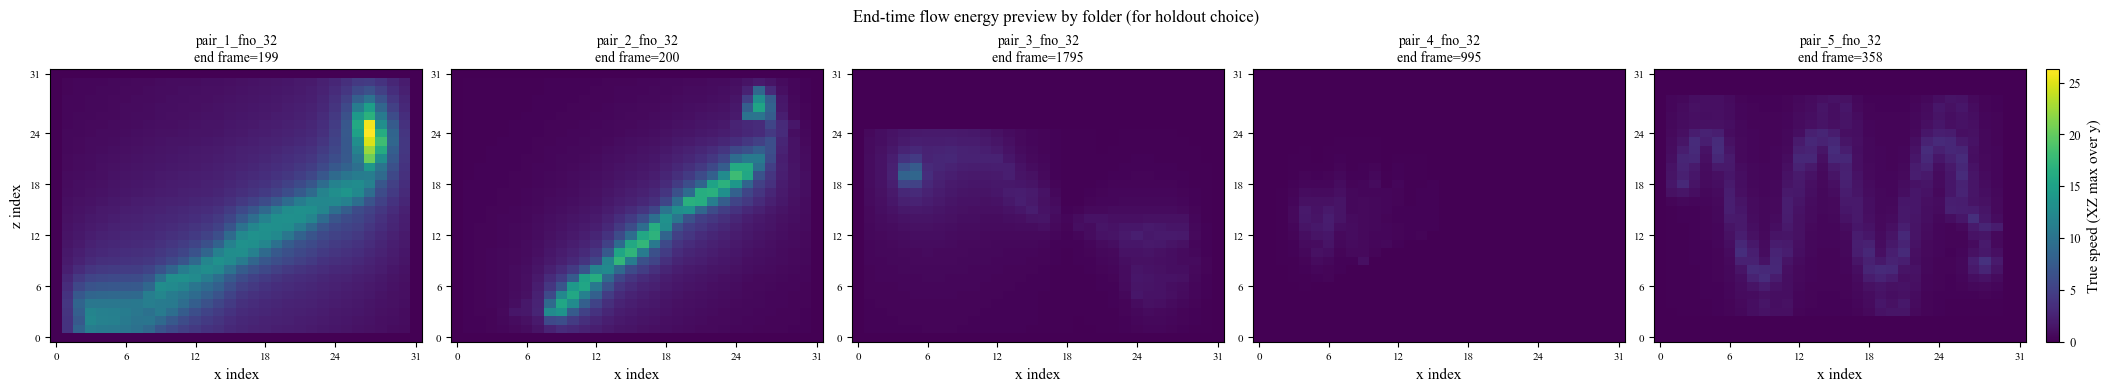

[preview] folder=pair_1_fno_32 end_frame=199
[preview] folder=pair_2_fno_32 end_frame=200
[preview] folder=pair_3_fno_32 end_frame=1795
[preview] folder=pair_4_fno_32 end_frame=995
[preview] folder=pair_5_fno_32 end_frame=358
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_convergence_primary_bundle.png


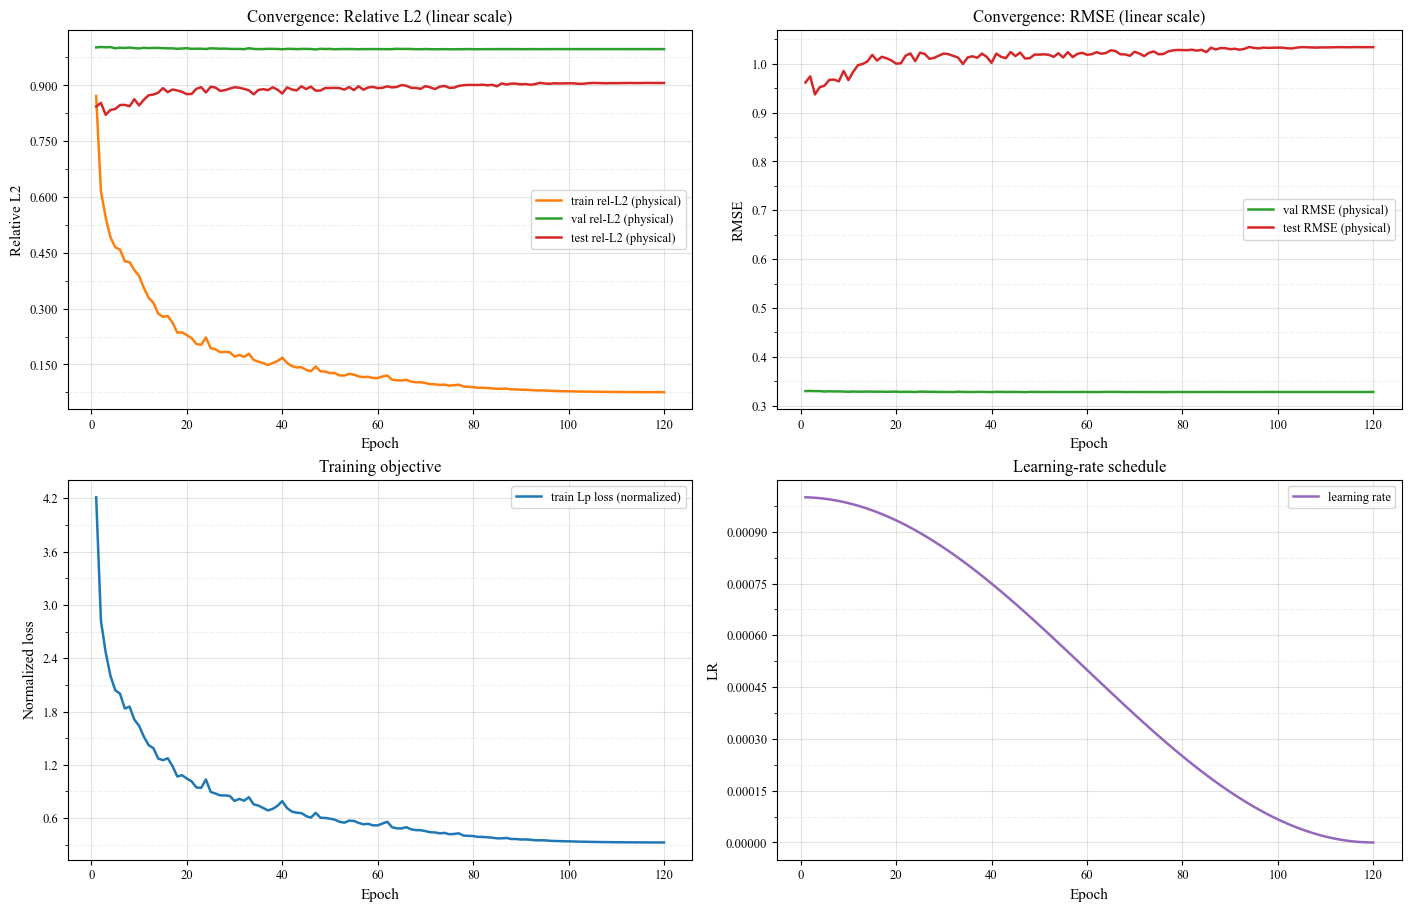

[TEST (unseen folder)] timeline folder=pair_2_fno_32, selected idx=[25, 46, 69, 88]
[note] idx = position in split list; frame = simulation timestep parsed from filename.
[note] These panels use max projection over y (entire y-domain), so no active-y slice index is used.
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_test_timeline_3x4.png


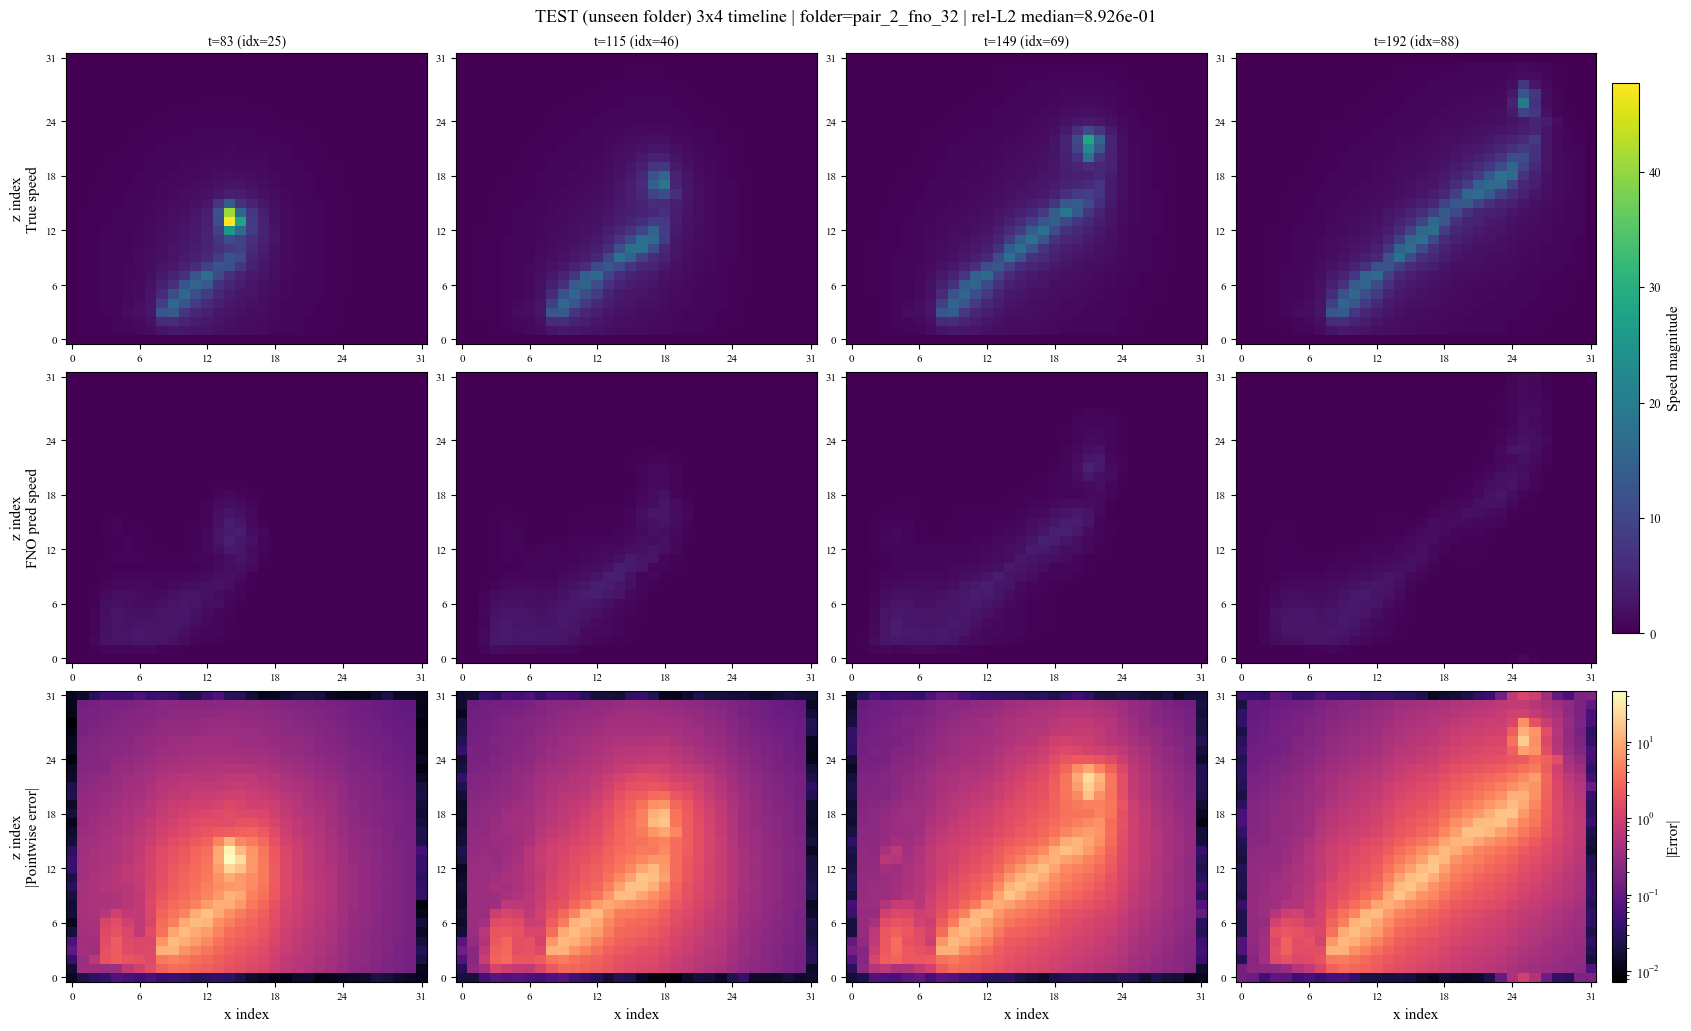

  TEST (unseen folder): folder=pair_2_fno_32 frame=83 idx=25 rel-L2=8.987e-01 file=frame_83_grid.npz
  TEST (unseen folder): folder=pair_2_fno_32 frame=115 idx=46 rel-L2=8.866e-01 file=frame_115_grid.npz
  TEST (unseen folder): folder=pair_2_fno_32 frame=149 idx=69 rel-L2=8.735e-01 file=frame_149_grid.npz
  TEST (unseen folder): folder=pair_2_fno_32 frame=192 idx=88 rel-L2=9.376e-01 file=frame_192_grid.npz
[VAL] timeline folder=pair_3_fno_32, selected idx=[25, 46, 69, 88]
[note] idx = position in split list; frame = simulation timestep parsed from filename.
[note] These panels use max projection over y (entire y-domain), so no active-y slice index is used.
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_val_timeline_3x4.png


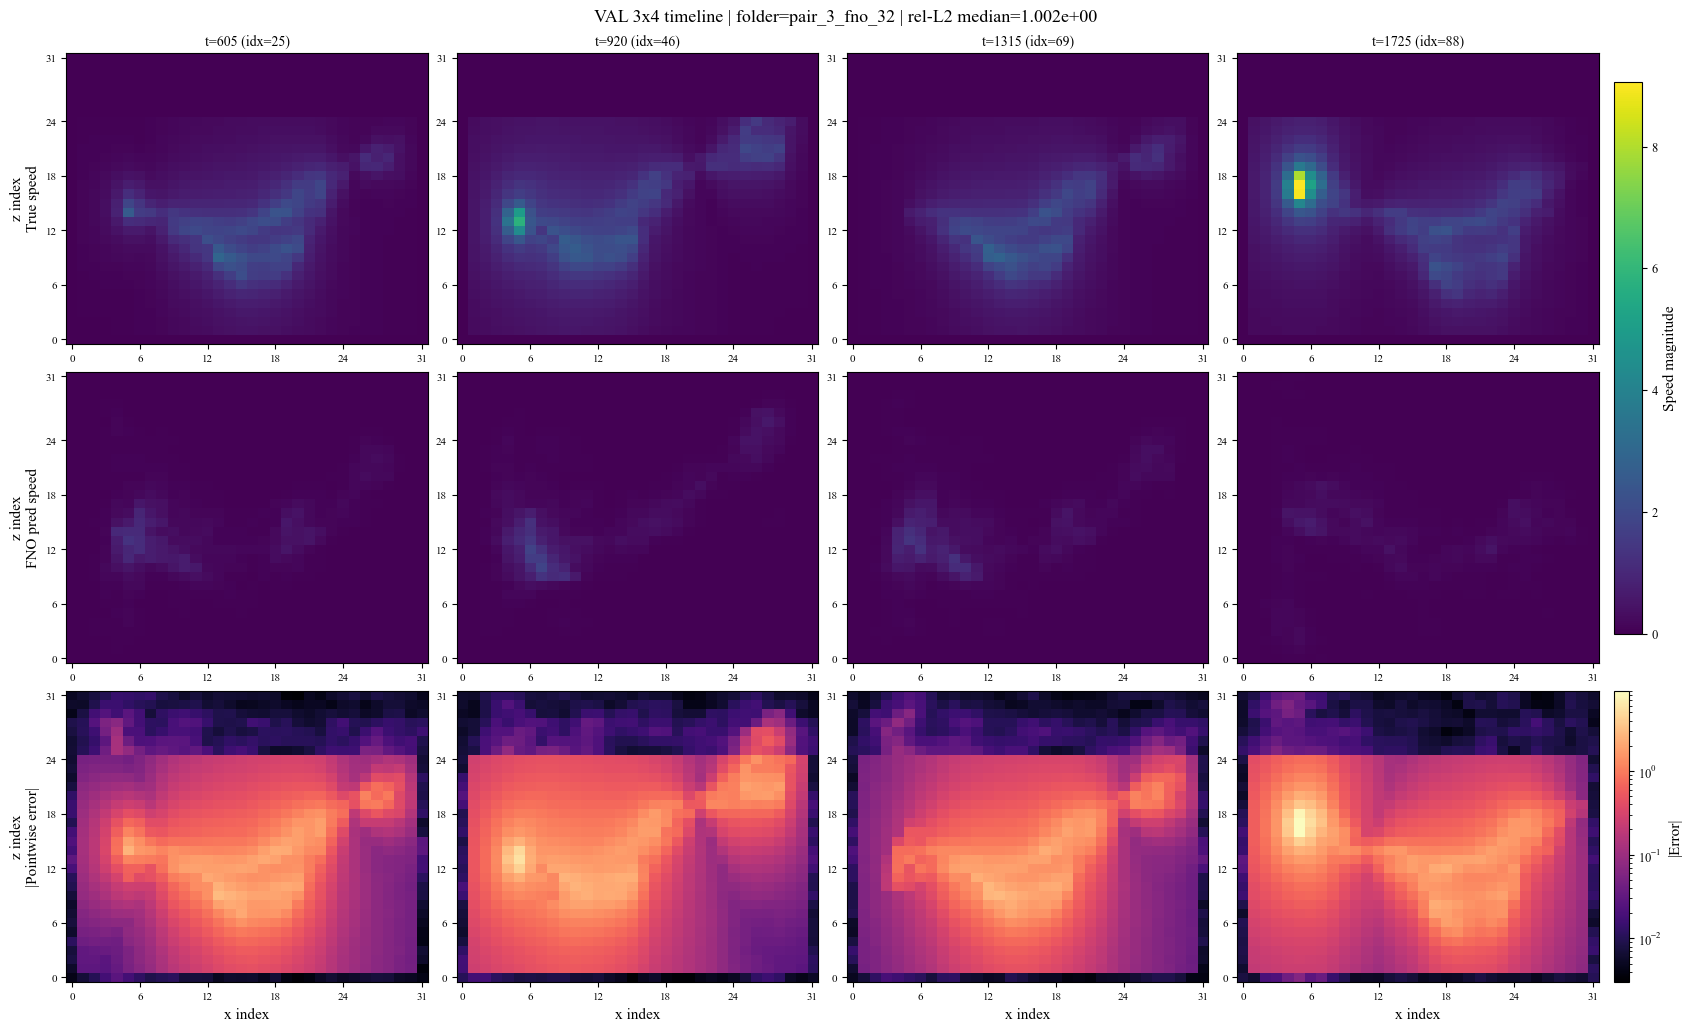

  VAL: folder=pair_3_fno_32 frame=605 idx=25 rel-L2=1.010e+00 file=frame_605_grid.npz
  VAL: folder=pair_3_fno_32 frame=920 idx=46 rel-L2=9.861e-01 file=frame_920_grid.npz
  VAL: folder=pair_3_fno_32 frame=1315 idx=69 rel-L2=1.009e+00 file=frame_1315_grid.npz
  VAL: folder=pair_3_fno_32 frame=1725 idx=88 rel-L2=9.948e-01 file=frame_1725_grid.npz
[TRAIN] timeline folder=pair_1_fno_32, selected idx=[24, 44, 67, 85]
[note] idx = position in split list; frame = simulation timestep parsed from filename.
[note] These panels use max projection over y (entire y-domain), so no active-y slice index is used.
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_train_timeline_3x4.png


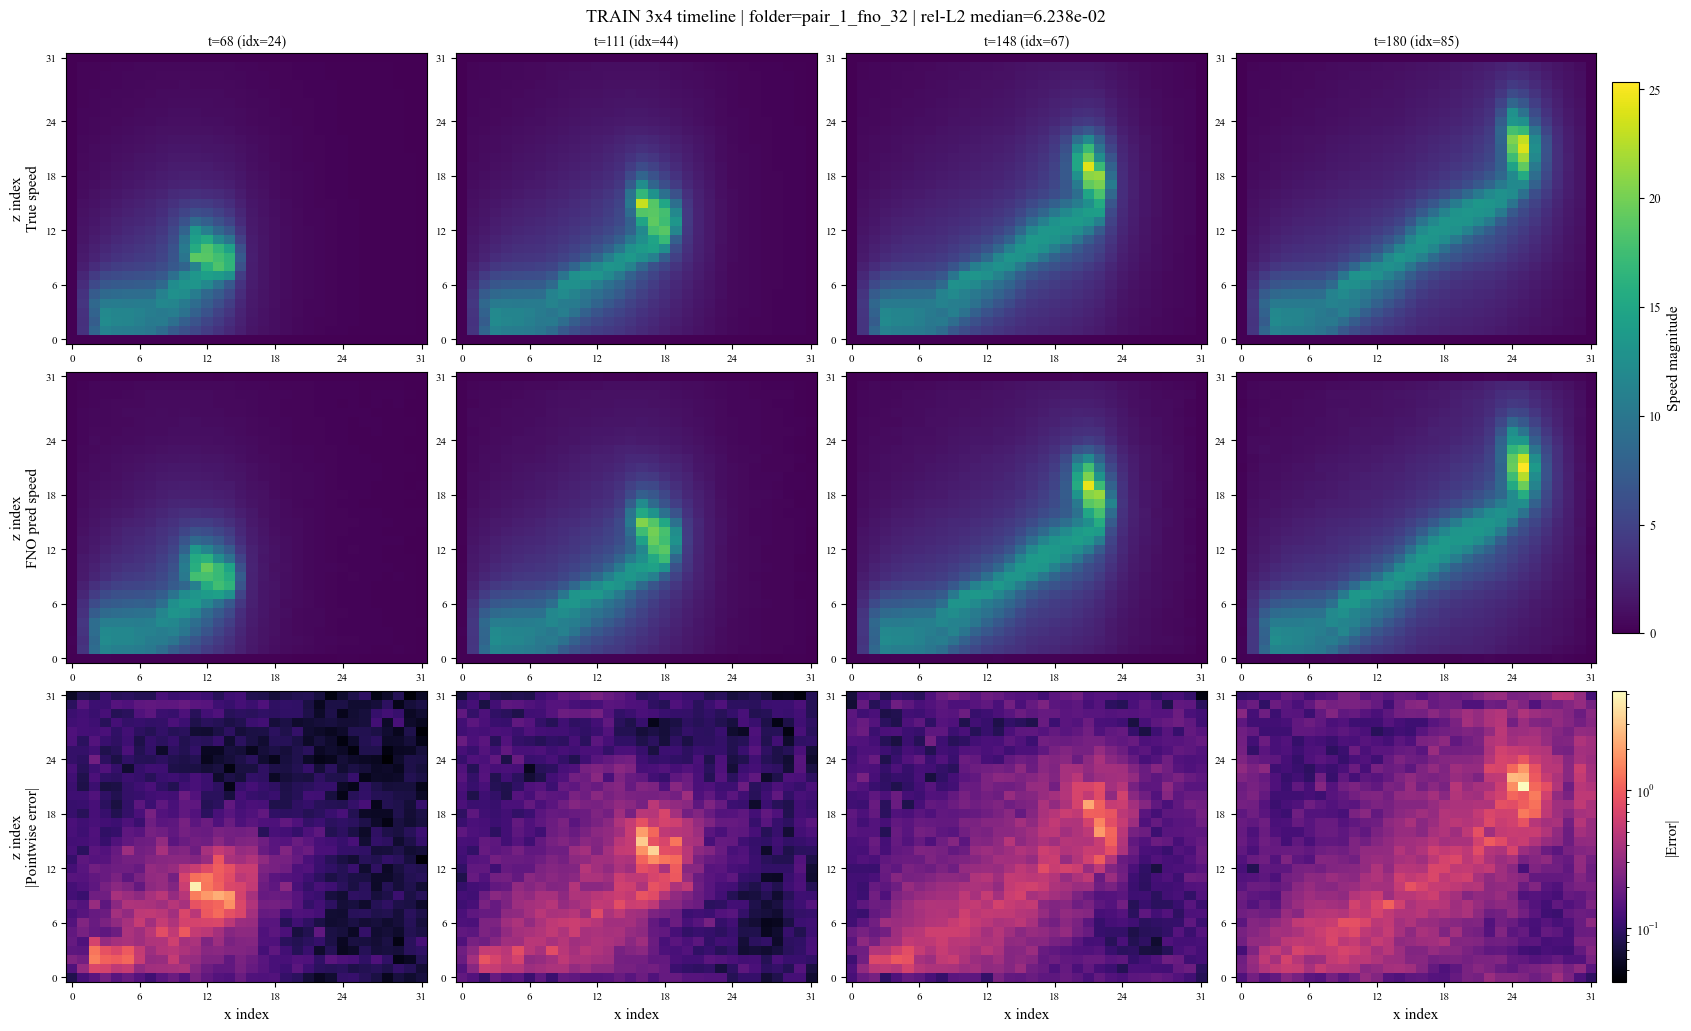

  TRAIN: folder=pair_1_fno_32 frame=68 idx=24 rel-L2=7.080e-02 file=frame_68_grid.npz
  TRAIN: folder=pair_1_fno_32 frame=111 idx=44 rel-L2=5.594e-02 file=frame_111_grid.npz
  TRAIN: folder=pair_1_fno_32 frame=148 idx=67 rel-L2=5.583e-02 file=frame_148_grid.npz
  TRAIN: folder=pair_1_fno_32 frame=180 idx=85 rel-L2=6.881e-02 file=frame_180_grid.npz
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_test_orthogonal_planes.png


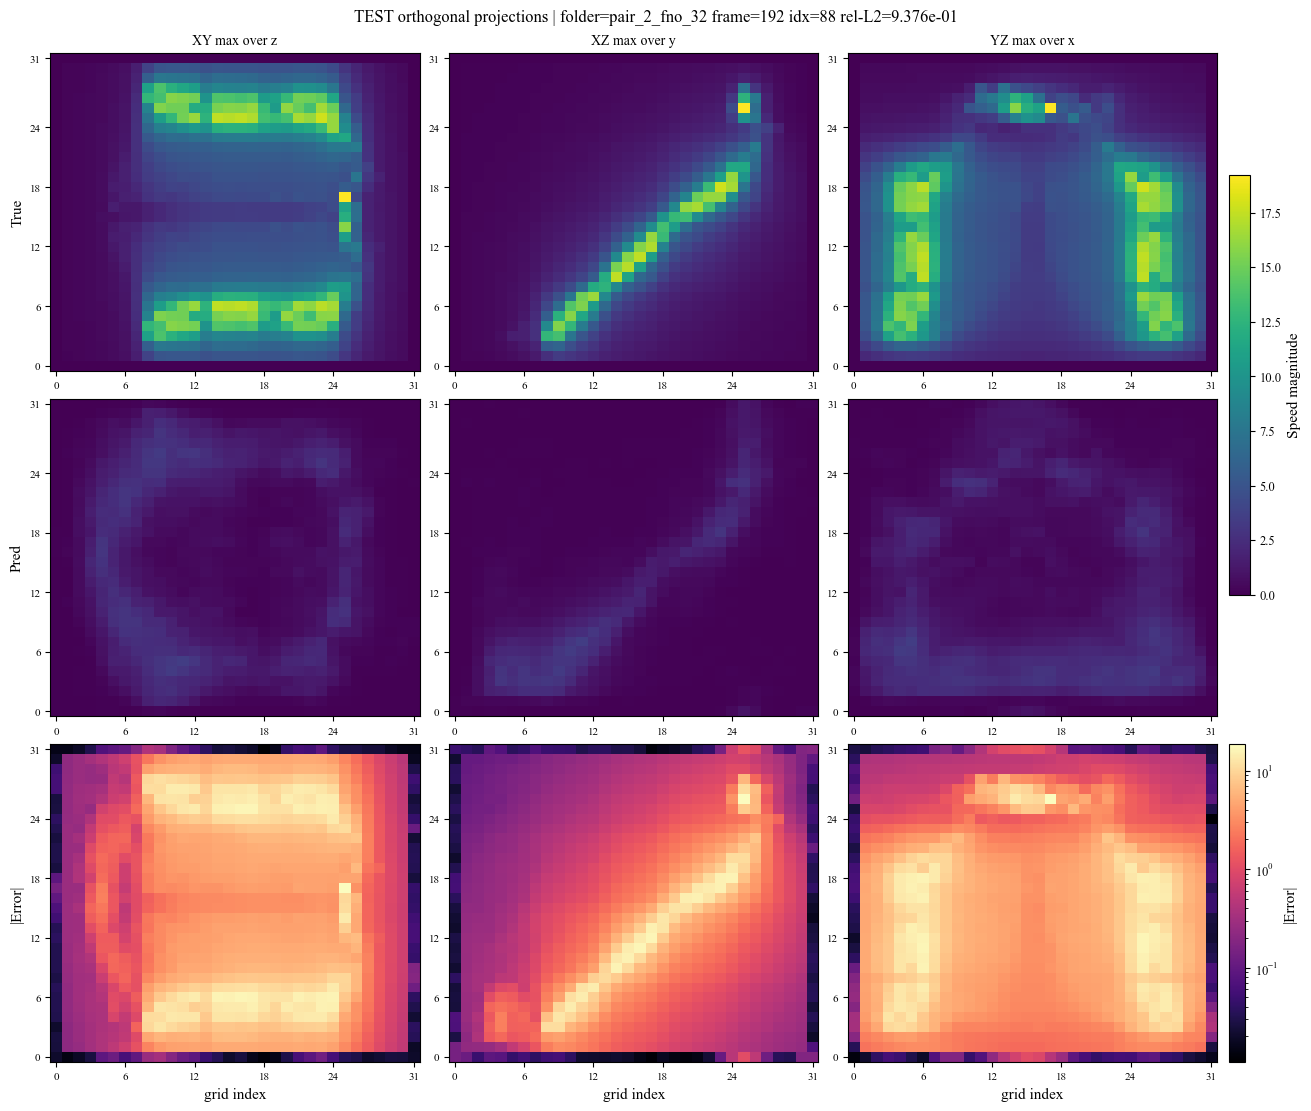

[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_val_orthogonal_planes.png


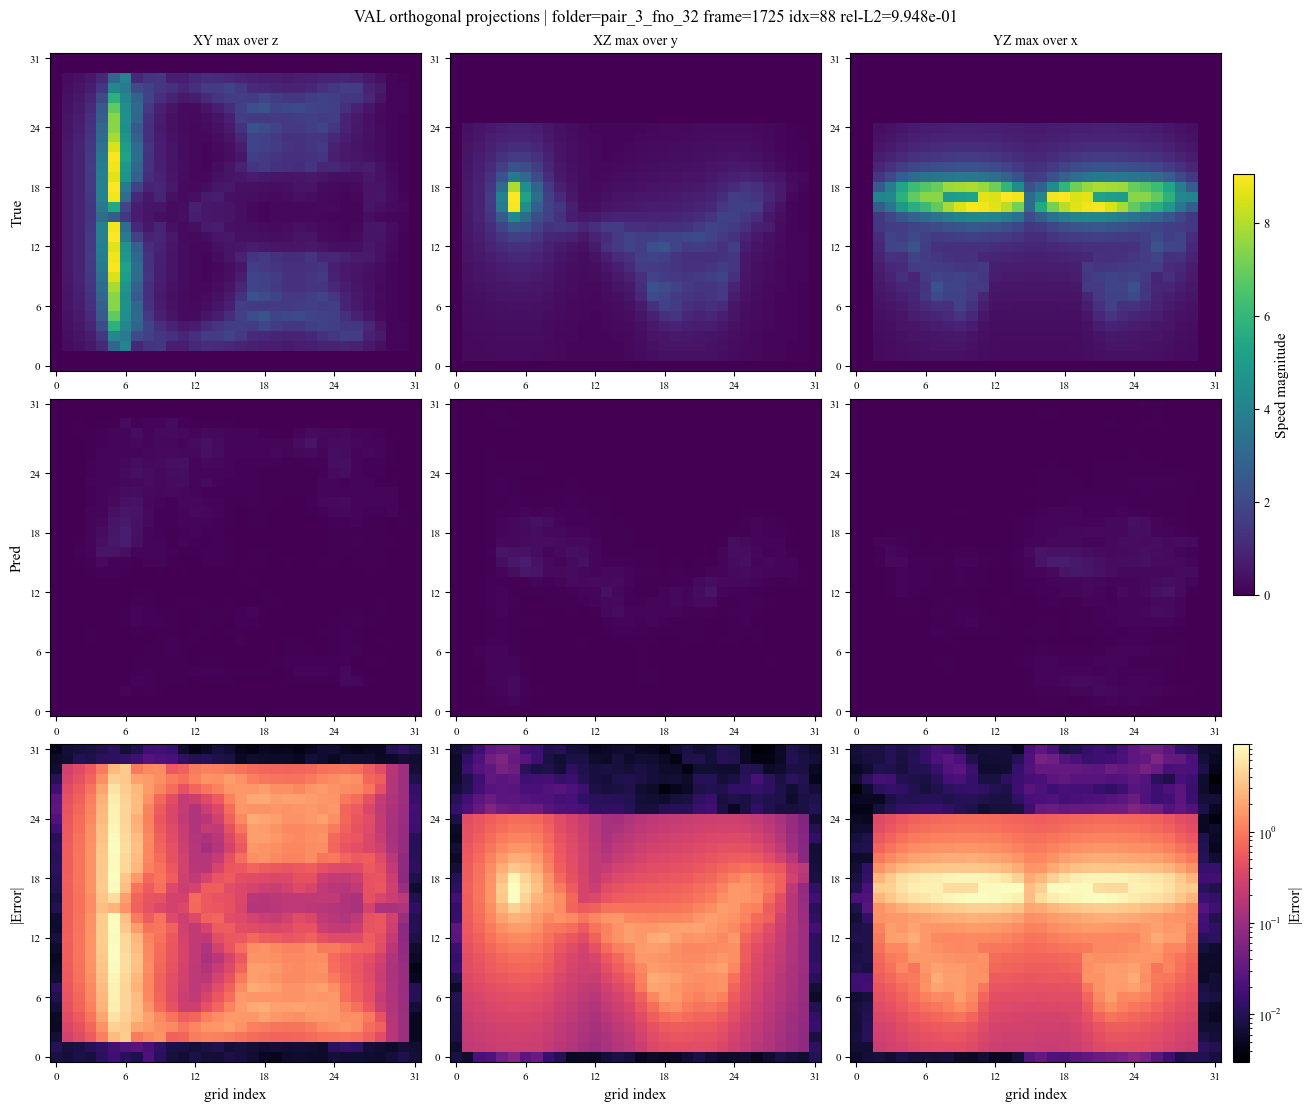

[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_model3_3d_qualitative_train_orthogonal_planes.png


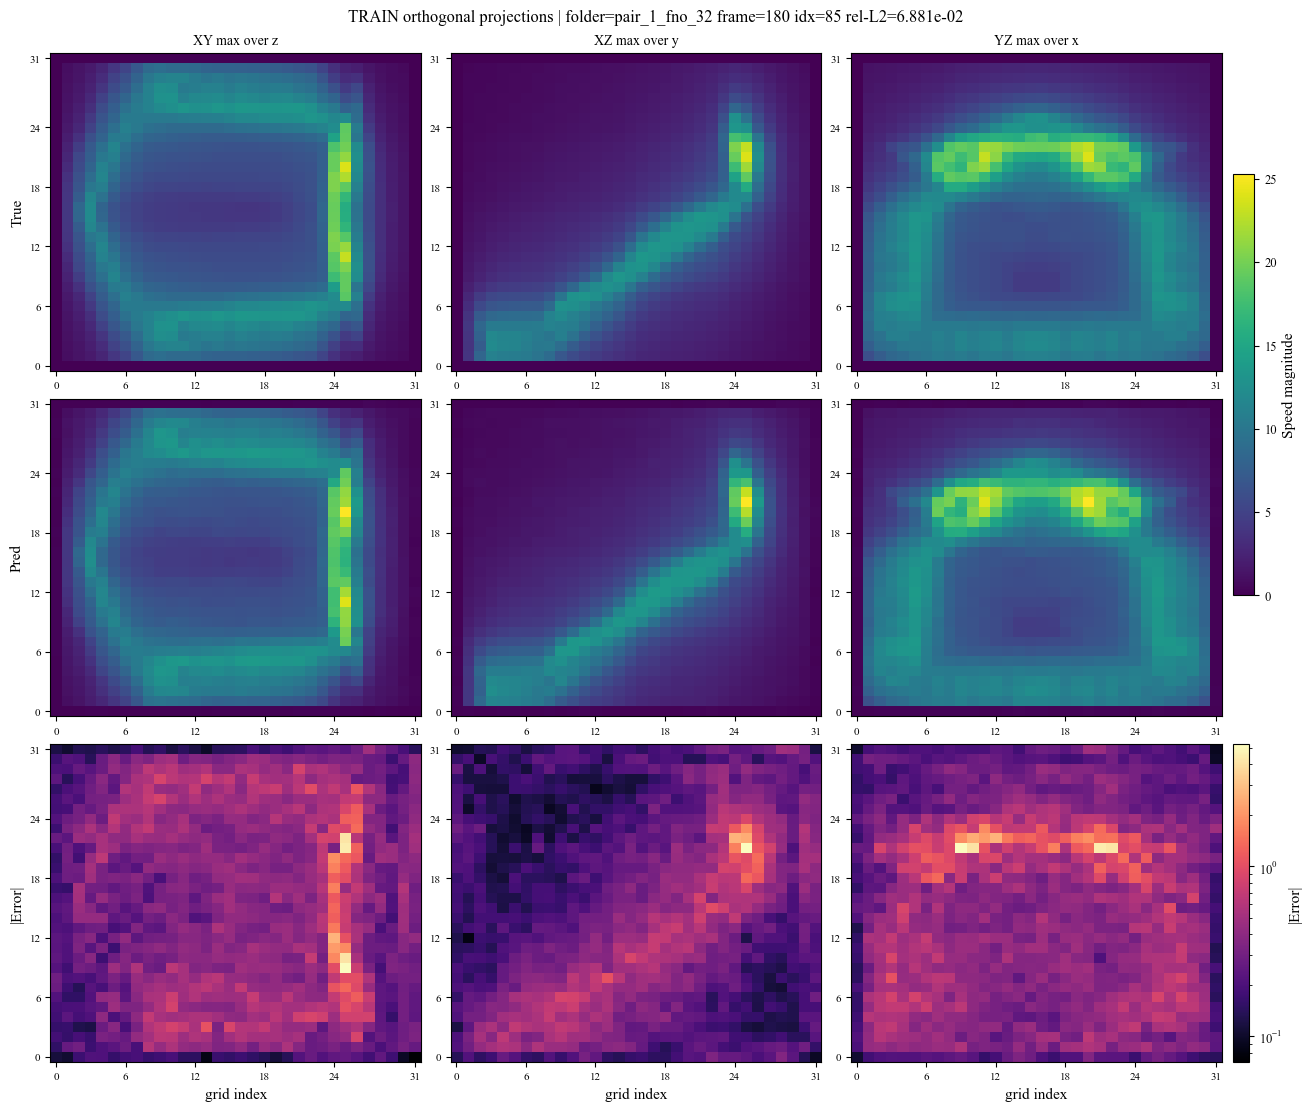

In [6]:
# =========================
# Primary plots (Convergence + Reconstruction Timeline + 3D planes)
# =========================
from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, FormatStrFormatter

if CFG.get('use_best_checkpoint_for_reports', True) and CKPT_PATH.exists():
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()
    print('[info] loaded best checkpoint for reporting:', CKPT_PATH)

FIELD_CMAP = CFG.get('plot_field_cmap', 'viridis')
ERROR_CMAP = CFG.get('plot_error_cmap', 'magma')


def speed_from_velocity(u_chw):
    # Convert velocity channels [Ux, Uy, Uz] to scalar speed [Nx, Ny, Nz].
    return torch.linalg.norm(u_chw, dim=0).cpu().numpy()


def xz_max_projection(vol):
    return np.max(vol, axis=1)


def orthogonal_max_projections(vol):
    return {
        'XY max over z': np.max(vol, axis=2).T,
        'XZ max over y': np.max(vol, axis=1).T,
        'YZ max over x': np.max(vol, axis=0).T,
    }


def style_axis_with_dense_ticks(ax, x_count, y_count, n_ticks=6):
    xt = np.linspace(0, max(x_count - 1, 0), num=min(n_ticks, max(x_count, 1)), dtype=int)
    yt = np.linspace(0, max(y_count - 1, 0), num=min(n_ticks, max(y_count, 1)), dtype=int)
    ax.set_xticks(np.unique(xt))
    ax.set_yticks(np.unique(yt))
    ax.tick_params(axis='both', which='major', labelsize=8)


def style_curve_axis(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, which='major', alpha=0.35)
    ax.grid(True, which='minor', alpha=0.20, linestyle='--')


@torch.no_grad()
def sample_prediction(ds, files, idx):
    x_norm, y_norm = ds[idx]
    p_norm = predict(MODEL, x_norm.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING))[0].cpu()

    y_phys = to_physical_y(y_norm)
    p_phys = to_physical_y(p_norm)
    true_speed = speed_from_velocity(y_phys)
    pred_speed = speed_from_velocity(p_phys)
    err_speed = np.abs(pred_speed - true_speed)
    rel = (
        torch.linalg.norm((p_phys - y_phys).reshape(-1))
        / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
    ).item()
    fp = Path(files[idx])
    return {
        'idx': idx,
        'frame': parse_frame_id(fp),
        'folder': fp.parent.name,
        'file': fp.name,
        'true_speed': true_speed,
        'pred_speed': pred_speed,
        'err_speed': err_speed,
        'rel_l2': rel,
    }


def choose_distant_indices_same_folder(files, min_frame=0, n_cols=4, fractions=None, start_frac=0.10, preferred_folder=None):
    rows = []
    for i, f in enumerate(files):
        fr = parse_frame_id(f)
        if min_frame not in (None, 0) and fr < min_frame:
            continue
        fp = Path(f)
        rows.append((i, fp.parent.name, fr, f))

    if len(rows) == 0:
        return None, []

    grouped = defaultdict(list)
    for r in rows:
        grouped[r[1]].append(r)
    for k in grouped:
        grouped[k] = sorted(grouped[k], key=lambda t: t[2])

    chosen_folder = preferred_folder if preferred_folder in grouped else max(grouped.keys(), key=lambda k: len(grouped[k]))
    folder_rows = grouped[chosen_folder]
    if len(folder_rows) == 0:
        return chosen_folder, []

    start_idx = max(1, int(round(start_frac * max(len(folder_rows) - 1, 1))))
    cand = folder_rows[start_idx:] if start_idx < len(folder_rows) else folder_rows
    if len(cand) == 0:
        cand = folder_rows

    if fractions is None:
        fractions = [0.18, 0.42, 0.70, 0.92]
    fractions = list(fractions)[:n_cols]
    if len(fractions) < n_cols:
        fractions = fractions + [fractions[-1]] * (n_cols - len(fractions))

    pos = [int(round(f * (len(cand) - 1))) for f in fractions]
    pos = [max(0, min(len(cand) - 1, p)) for p in pos]

    # Deduplicate while preserving order, then fill if needed.
    uniq = []
    for p in pos:
        if p not in uniq:
            uniq.append(p)
    k = 0
    while len(uniq) < min(n_cols, len(cand)):
        if k not in uniq:
            uniq.append(k)
        k += 1

    uniq = uniq[:min(n_cols, len(cand))]
    selected = [cand[p][0] for p in uniq]
    return chosen_folder, selected


def plot_timeline_3x4(ds, files, split_name, min_frame, preferred_folder, save_tag):
    if ds is None or len(files) == 0:
        print(f'[skip] {split_name}: empty split')
        return None

    folder_name, idxs = choose_distant_indices_same_folder(
        files,
        min_frame=min_frame,
        n_cols=int(CFG.get('timeline_n_cols', 4)),
        fractions=CFG.get('timeline_fractions', [0.18, 0.42, 0.70, 0.92]),
        start_frac=float(CFG.get('timeline_start_frac', 0.10)),
        preferred_folder=preferred_folder,
    )
    if len(idxs) == 0:
        print(f'[skip] {split_name}: no valid snapshot indices selected')
        return None

    print(f"[{split_name}] timeline folder={folder_name}, selected idx={idxs}")
    print('[note] idx = position in split list; frame = simulation timestep parsed from filename.')
    print('[note] These panels use max projection over y (entire y-domain), so no active-y slice index is used.')

    samples = [sample_prediction(ds, files, i) for i in idxs]
    true_proj = [xz_max_projection(s['true_speed']) for s in samples]
    pred_proj = [xz_max_projection(s['pred_speed']) for s in samples]
    err_proj = [xz_max_projection(s['err_speed']) for s in samples]

    all_field_vals = np.concatenate([a.reshape(-1) for a in (true_proj + pred_proj)])
    field_vmin = float(np.min(all_field_vals))
    field_vmax = float(np.max(all_field_vals))

    all_err_vals = np.concatenate([a.reshape(-1) for a in err_proj])
    err_vmin = max(float(np.min(all_err_vals)), 1e-8)
    err_vmax = max(float(np.max(all_err_vals)), err_vmin * 10.0)

    n_cols = len(samples)
    fig, axs = plt.subplots(3, n_cols, figsize=(4.2 * n_cols, 10.2), constrained_layout=True)
    if n_cols == 1:
        axs = np.asarray(axs).reshape(3, 1)

    for j, s in enumerate(samples):
        t = true_proj[j]
        p = pred_proj[j]
        e = err_proj[j]

        im_t = axs[0, j].imshow(t.T, cmap=FIELD_CMAP, vmin=field_vmin, vmax=field_vmax, origin='lower', aspect='auto')
        im_p = axs[1, j].imshow(p.T, cmap=FIELD_CMAP, vmin=field_vmin, vmax=field_vmax, origin='lower', aspect='auto')
        im_e = axs[2, j].imshow(e.T, cmap=ERROR_CMAP, norm=LogNorm(vmin=err_vmin, vmax=err_vmax), origin='lower', aspect='auto')

        axs[0, j].set_title(f"t={s['frame']} (idx={s['idx']})", fontsize=10)
        style_axis_with_dense_ticks(axs[0, j], t.shape[0], t.shape[1], n_ticks=6)
        style_axis_with_dense_ticks(axs[1, j], p.shape[0], p.shape[1], n_ticks=6)
        style_axis_with_dense_ticks(axs[2, j], e.shape[0], e.shape[1], n_ticks=6)
        axs[2, j].set_xlabel('x index')

        if j == 0:
            axs[0, j].set_ylabel('z index\nTrue speed')
            axs[1, j].set_ylabel('z index\nFNO pred speed')
            axs[2, j].set_ylabel('z index\n|Pointwise error|')

    cbar_field = fig.colorbar(im_t, ax=axs[0, :].tolist() + axs[1, :].tolist(), fraction=0.018, pad=0.01)
    cbar_field.set_label('Speed magnitude')
    cbar_err = fig.colorbar(im_e, ax=axs[2, :].tolist(), fraction=0.018, pad=0.01)
    cbar_err.set_label('|Error|')

    rels = [s['rel_l2'] for s in samples]
    fig.suptitle(
        f"{split_name} 3x{n_cols} timeline | folder={folder_name} | rel-L2 median={np.median(rels):.3e}",
        fontsize=13,
    )
    save_fig(fig, f'qualitative_{save_tag}_timeline_3x{n_cols}.png')
    plt.show()

    for s in samples:
        print(f"  {split_name}: folder={s['folder']} frame={s['frame']} idx={s['idx']} rel-L2={s['rel_l2']:.3e} file={s['file']}")

    return {'folder': folder_name, 'selected_indices': idxs, 'samples': samples}


def plot_orthogonal_planes(ds, files, split_name, sample_idx, save_tag):
    if ds is None or len(files) == 0:
        return
    s = sample_prediction(ds, files, sample_idx)
    tp = orthogonal_max_projections(s['true_speed'])
    pp = orthogonal_max_projections(s['pred_speed'])
    ep = orthogonal_max_projections(s['err_speed'])

    all_field_vals = np.concatenate([v.reshape(-1) for v in list(tp.values()) + list(pp.values())])
    field_vmin = float(np.min(all_field_vals))
    field_vmax = float(np.max(all_field_vals))
    all_err_vals = np.concatenate([v.reshape(-1) for v in ep.values()])
    err_vmin = max(float(np.min(all_err_vals)), 1e-8)
    err_vmax = max(float(np.max(all_err_vals)), err_vmin * 10.0)

    fig, axs = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
    names = list(tp.keys())
    for j, name in enumerate(names):
        t = tp[name]
        p = pp[name]
        e = ep[name]
        im_t = axs[0, j].imshow(t, cmap=FIELD_CMAP, vmin=field_vmin, vmax=field_vmax, origin='lower', aspect='auto')
        im_p = axs[1, j].imshow(p, cmap=FIELD_CMAP, vmin=field_vmin, vmax=field_vmax, origin='lower', aspect='auto')
        im_e = axs[2, j].imshow(e, cmap=ERROR_CMAP, norm=LogNorm(vmin=err_vmin, vmax=err_vmax), origin='lower', aspect='auto')
        axs[0, j].set_title(name, fontsize=10)
        style_axis_with_dense_ticks(axs[0, j], t.shape[1], t.shape[0], n_ticks=6)
        style_axis_with_dense_ticks(axs[1, j], p.shape[1], p.shape[0], n_ticks=6)
        style_axis_with_dense_ticks(axs[2, j], e.shape[1], e.shape[0], n_ticks=6)
        if j == 0:
            axs[0, j].set_ylabel('True')
            axs[1, j].set_ylabel('Pred')
            axs[2, j].set_ylabel('|Error|')
        axs[2, j].set_xlabel('grid index')

    cbar_field = fig.colorbar(im_t, ax=axs[0, :].tolist() + axs[1, :].tolist(), fraction=0.018, pad=0.01)
    cbar_field.set_label('Speed magnitude')
    cbar_err = fig.colorbar(im_e, ax=axs[2, :].tolist(), fraction=0.018, pad=0.01)
    cbar_err.set_label('|Error|')
    fig.suptitle(
        f"{split_name} orthogonal projections | folder={s['folder']} frame={s['frame']} idx={s['idx']} rel-L2={s['rel_l2']:.3e}",
        fontsize=12,
    )
    save_fig(fig, f'qualitative_{save_tag}_orthogonal_planes.png')
    plt.show()


def plot_convergence_bundle():
    if len(HIST['epoch']) == 0:
        print('[skip] Convergence plot: history is empty')
        return

    fig, axs = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    colors = {
        'train_lp': '#1f77b4',
        'train_rel': '#ff7f0e',
        'val_rel': '#2ca02c',
        'test_rel': '#d62728',
        'val_rmse': '#2ca02c',
        'test_rmse': '#d62728',
        'lr': '#9467bd',
    }

    axs[0, 0].plot(HIST['epoch'], HIST['train_rel_l2'], color=colors['train_rel'], linewidth=1.8, label='train rel-L2 (physical)')
    axs[0, 0].plot(HIST['epoch'], HIST['val_rel_l2'], color=colors['val_rel'], linewidth=1.8, label='val rel-L2 (physical)')
    if HAS_TEST:
        axs[0, 0].plot(HIST['epoch'], HIST['test_rel_l2'], color=colors['test_rel'], linewidth=1.8, label='test rel-L2 (physical)')
    style_curve_axis(axs[0, 0], 'Epoch', 'Relative L2')
    axs[0, 0].set_title('Convergence: Relative L2 (linear scale)')
    axs[0, 0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    axs[0, 0].legend()

    axs[0, 1].plot(HIST['epoch'], HIST['val_rmse'], color=colors['val_rmse'], linewidth=1.8, label='val RMSE (physical)')
    if HAS_TEST:
        axs[0, 1].plot(HIST['epoch'], HIST['test_rmse'], color=colors['test_rmse'], linewidth=1.8, label='test RMSE (physical)')
    style_curve_axis(axs[0, 1], 'Epoch', 'RMSE')
    axs[0, 1].set_title('Convergence: RMSE (linear scale)')
    axs[0, 1].legend()

    axs[1, 0].plot(HIST['epoch'], HIST['train_lp'], color=colors['train_lp'], linewidth=1.8, label='train Lp loss (normalized)')
    style_curve_axis(axs[1, 0], 'Epoch', 'Normalized loss')
    axs[1, 0].set_title('Training objective')
    axs[1, 0].legend()

    axs[1, 1].plot(HIST['epoch'], HIST['lr'], color=colors['lr'], linewidth=1.8, label='learning rate')
    style_curve_axis(axs[1, 1], 'Epoch', 'LR')
    axs[1, 1].set_title('Learning-rate schedule')
    axs[1, 1].legend()

    save_fig(fig, 'convergence_primary_bundle.png')
    plt.show()


def plot_end_snapshot_energy_gallery(candidate_dirs):
    if len(candidate_dirs) == 0:
        print('[skip] candidate preview dirs are empty')
        return

    previews = []
    for d in candidate_dirs:
        files = list_frame_files(d, expect_gridded=True)
        files = filter_valid_gridded_files(
            files,
            input_key=CFG['input_key'],
            expected_channels=CFG['input_channels'],
            label=f'{d.name} (preview)',
            max_report=2,
        )
        files = filter_by_min_frame(files, CFG['min_frame_test'], f'{d.name} (preview)')
        if len(files) == 0:
            continue
        fp = sorted(files, key=parse_frame_id)[-1]
        d_npz = np.load(fp)
        y = torch.tensor(np.asarray(d_npz['U_grid'], dtype=np.float32), dtype=torch.float32)
        speed = speed_from_velocity(y)
        xz = xz_max_projection(speed)
        previews.append({
            'folder': d.name,
            'frame': parse_frame_id(fp),
            'xz': xz,
        })

    if len(previews) == 0:
        print('[skip] no valid preview snapshots found')
        return

    vals = np.concatenate([p['xz'].reshape(-1) for p in previews])
    vmin = float(np.min(vals))
    vmax = float(np.max(vals))

    fig, axs = plt.subplots(1, len(previews), figsize=(4.2 * len(previews), 3.8), constrained_layout=True)
    if len(previews) == 1:
        axs = [axs]
    for i, p in enumerate(previews):
        im = axs[i].imshow(p['xz'].T, cmap=FIELD_CMAP, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
        axs[i].set_title(f"{p['folder']}\nend frame={p['frame']}", fontsize=10)
        style_axis_with_dense_ticks(axs[i], p['xz'].shape[0], p['xz'].shape[1], n_ticks=6)
        axs[i].set_xlabel('x index')
        if i == 0:
            axs[i].set_ylabel('z index')
    cbar = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.01)
    cbar.set_label('True speed (XZ max over y)')
    fig.suptitle('End-time flow energy preview by folder (for holdout choice)', fontsize=12)
    save_fig(fig, 'test_folder_end_snapshot_preview.png')
    plt.show()
    for p in previews:
        print(f"[preview] folder={p['folder']} end_frame={p['frame']}")


print('Running folder preview + primary convergence/reconstruction diagnostics...')
plot_end_snapshot_energy_gallery(PREVIEW_DIRS)
plot_convergence_bundle()

test_meta = None
if HAS_TEST:
    test_meta = plot_timeline_3x4(
        TEST_DS,
        TEST_FILES,
        split_name='TEST (unseen folder)',
        min_frame=CFG['min_frame_test'],
        preferred_folder=CFG.get('preferred_test_folder'),
        save_tag='test',
    )
else:
    print('[warn] TEST split is empty: no unseen-folder timeline can be plotted.')

val_meta = plot_timeline_3x4(
    VAL_DS,
    VAL_FILES,
    split_name='VAL',
    min_frame=CFG['min_frame_trainval'],
    preferred_folder=CFG.get('preferred_val_folder'),
    save_tag='val',
)

train_meta = plot_timeline_3x4(
    TRAIN_DS,
    TRAIN_FILES,
    split_name='TRAIN',
    min_frame=CFG['min_frame_trainval'],
    preferred_folder=CFG.get('preferred_train_folder'),
    save_tag='train',
)

# 3D depiction through orthogonal max-projection planes for one late snapshot per split.
if test_meta is not None and len(test_meta['selected_indices']) > 0:
    plot_orthogonal_planes(TEST_DS, TEST_FILES, 'TEST', test_meta['selected_indices'][-1], save_tag='test')
if val_meta is not None and len(val_meta['selected_indices']) > 0:
    plot_orthogonal_planes(VAL_DS, VAL_FILES, 'VAL', val_meta['selected_indices'][-1], save_tag='val')
if train_meta is not None and len(train_meta['selected_indices']) > 0:
    plot_orthogonal_planes(TRAIN_DS, TRAIN_FILES, 'TRAIN', train_meta['selected_indices'][-1], save_tag='train')


In [7]:
# =========================
# Optional diagnostics (disabled by default)
# =========================
if CFG.get('enable_optional_plots', False):
    print('[info] Optional distribution/parity diagnostics can be added here when needed.')
else:
    print('[skip] Optional distribution/parity diagnostics disabled to keep the primary workflow focused.')


[skip] Optional distribution/parity diagnostics disabled to keep the primary workflow focused.


In [8]:
# =========================
# Snapshot panel note
# =========================
print('[info] Reconstruction timelines are now generated in snippet 6 as 3x4 panels for TEST/VAL/TRAIN.')
print('[info] Each 3x4 panel uses one folder per split and four distant time snapshots from the same dataset.')


[info] Reconstruction timelines are now generated in snippet 6 as 3x4 panels for TEST/VAL/TRAIN.
[info] Each 3x4 panel uses one folder per split and four distant time snapshots from the same dataset.


In [9]:
# =========================
# Optional misc diagnostics placeholder
# =========================
print('[skip] Data-hunger diagnostics are disabled for now to keep the primary workflow focused.')
print("[info] Set CFG['enable_optional_plots']=True and re-add this cell if you want data-hunger runs later.")


[skip] Data-hunger diagnostics are disabled for now to keep the primary workflow focused.
[info] Set CFG['enable_optional_plots']=True and re-add this cell if you want data-hunger runs later.


In [10]:
# =========================
# Optional sweep diagnostics placeholder
# =========================
print('[skip] Sensitivity sweeps are disabled for now to avoid confusion with the primary reconstruction workflow.')
print("[info] Hidden-channel sweep compares quick retrains with modified configs; it does not claim your main run used all sweep values.")


[skip] Sensitivity sweeps are disabled for now to avoid confusion with the primary reconstruction workflow.
[info] Hidden-channel sweep compares quick retrains with modified configs; it does not claim your main run used all sweep values.


In [11]:
# =========================
# Optional data profile placeholder
# =========================
print('[skip] Standalone 3D data-profile scatter plots are disabled for now.')
print('[info] 3D reconstruction interpretation is now centered in snippet 6 via timeline and orthogonal-plane views.')


[skip] Standalone 3D data-profile scatter plots are disabled for now.
[info] 3D reconstruction interpretation is now centered in snippet 6 via timeline and orthogonal-plane views.


In [12]:
# =========================
# Optional IO flow demo placeholder
# =========================
print('[skip] The separate IO flow demo is disabled for now to avoid duplicate visuals.')
print('[info] Use snippet 6 outputs: convergence bundle, 3x4 timelines, and orthogonal-plane reconstructions.')


[skip] The separate IO flow demo is disabled for now to avoid duplicate visuals.
[info] Use snippet 6 outputs: convergence bundle, 3x4 timelines, and orthogonal-plane reconstructions.
